# Improved CNN for Guitar Type Classification

Improvements over the Baseline CNN:
- **OpenCV preprocessing**: background crop, CLAHE, edge sharpening
- **Deeper architecture**: 5 conv blocks with BatchNorm + Dropout
- **Strong augmentation**: RandomHorizontalFlip, RandomRotation, ColorJitter
- **Optimizer comparison**: Adam vs SGD across learning rates and batch sizes
- **LR scheduling**: ReduceLROnPlateau
- **Full evaluation**: Accuracy, Precision, Recall, F1, Confusion Matrix

## 1. Imports and Setup

In [1]:
import os
import copy
import time
import itertools

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

## 2. Configuration

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#  Paths 
DATA_DIR  = "processed_dataset"       # Preprocessed images (run preprocess_dataset.py first)
SAVE_DIR  = "."                        # Where to save model checkpoints

#  Image 
IMAGE_SIZE  = 224
NUM_CLASSES = 3

#  Dataset split 
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_SEED = 42

#  Hyperparameter grid (compared during experiment) 
OPTIMIZERS     = ["adam"]
LEARNING_RATES = [0.001, 0.0001, 0.00005]
BATCH_SIZES    = [16,32,64]

#  Fixed training settings 
NUM_EPOCHS   = 20
LR_PATIENCE  = 5    # ReduceLROnPlateau patience
LR_FACTOR    = 0.5  # LR reduction factor

#  Reproducibility 
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ImageNet stats (used for normalisation)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

## 3. Device Configuration

In [8]:
def get_device():
    """Detect best available device (CUDA A100 → CPU)."""
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")
        print(f"[INFO] VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    else:
        device = torch.device("cpu")
        print("[INFO] GPU not available — using CPU")
    return device

device = get_device()

[INFO] GPU: NVIDIA A100-SXM4-40GB
[INFO] VRAM: 42.4 GB


## 4. Data Transforms and Loading

In [15]:
def get_transforms(augment: bool = True):
    """
    Return image transforms.

    Args:
        augment: If True, apply training augmentations.
                 If False, apply val/test transforms only.
    """
    if augment:
        transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
            transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
    else:
        transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
    return transform


def load_data(batch_size: int):
    """
    Load processed_dataset with ImageFolder, split 70/15/15, return loaders.

    Args:
        batch_size: Mini-batch size for DataLoaders.

    Returns:
        train_loader, val_loader, test_loader, class_names
    """
    if not os.path.isdir(DATA_DIR):
        raise FileNotFoundError(
            f"[ERROR] '{DATA_DIR}' not found. "
            "Run preprocess_dataset.py first."
        )

    # Load with augmentation for training set
    full_aug  = ImageFolder(root=DATA_DIR, transform=get_transforms(augment=True))
    full_plain = ImageFolder(root=DATA_DIR, transform=get_transforms(augment=False))
    class_names = full_aug.classes
    n_total = len(full_aug)

    n_train = int(n_total * TRAIN_RATIO)
    n_val   = int(n_total * VAL_RATIO)
    n_test  = n_total - n_train - n_val

    generator = torch.Generator().manual_seed(RANDOM_SEED)
    indices = torch.randperm(n_total, generator=generator).tolist()
    train_idx = indices[:n_train]
    val_idx   = indices[n_train:n_train + n_val]
    test_idx  = indices[n_train + n_val:]

    from torch.utils.data import Subset
    train_dataset = Subset(full_aug,   train_idx)
    val_dataset   = Subset(full_plain, val_idx)
    test_dataset  = Subset(full_plain, test_idx)

    num_workers = 2

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                               shuffle=True, num_workers=num_workers,
                               pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size,
                               shuffle=False, num_workers=num_workers,
                               pin_memory=True, drop_last=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size,
                               shuffle=False, num_workers=num_workers,
                               pin_memory=True, drop_last=True)

    print(f"[INFO] Classes    : {class_names}")
    print(f"[INFO] Total      : {n_total}")
    print(f"[INFO]   Train    : {n_train} | Val: {n_val} | Test: {n_test}")

    return train_loader, val_loader, test_loader, class_names

## 5. Improved CNN Architecture

Architecture:

| Block | Layers                                      | Output shape        |
|-------|---------------------------------------------|---------------------|
| 1     | Conv(32) → BN → ReLU → MaxPool             | 32 × 112 × 112     |
| 2     | Conv(64) → BN → ReLU → MaxPool             | 64 × 56 × 56       |
| 3     | Conv(128) → BN → ReLU → MaxPool            | 128 × 28 × 28      |
| 4     | Conv(256) → BN → ReLU → MaxPool            | 256 × 14 × 14      |
| 5     | Conv(256) → BN → ReLU → AdaptiveAvgPool    | 256 × 4 × 4        |
|       | Flatten → Dropout(0.5)                      | 4096               |
|       | FC(512) → BN → ReLU → Dropout(0.3)         | 512                |
|       | FC(128) → ReLU → FC(3)                     | 3 (logits)         |

In [16]:
class ImprovedCNN(nn.Module):
    """
    Deeper CNN with BatchNorm, Dropout, and a stronger classifier head.

    Compared to BaselineCNN:
        - 5 conv blocks vs 3
        - BatchNorm after every convolution (training stability)
        - AdaptiveAvgPool replaces fixed-size flatten (flexible input size)
        - Dropout at 0.5 (feature maps) and 0.3 (FC) for regularisation
        - 3-layer fully-connected classifier
    """

    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()

        def conv_block(in_ch, out_ch):
            """Conv → BN → ReLU helper."""
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        #  Feature extractor 
        self.block1 = nn.Sequential(conv_block(3,   32),  nn.MaxPool2d(2, 2))
        self.block2 = nn.Sequential(conv_block(32,  64),  nn.MaxPool2d(2, 2))
        self.block3 = nn.Sequential(conv_block(64,  128), nn.MaxPool2d(2, 2))
        self.block4 = nn.Sequential(conv_block(128, 256), nn.MaxPool2d(2, 2))
        self.block5 = nn.Sequential(conv_block(256, 256),
                                    nn.AdaptiveAvgPool2d((4, 4)))

        #  Classifier 
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),

            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),

            nn.Linear(512, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.classifier(x)
        return x


def build_model(device: torch.device) -> ImprovedCNN:
    """Instantiate the model, print summary, return it on device."""
    model = ImprovedCNN(num_classes=NUM_CLASSES).to(device)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n[INFO] ImprovedCNN — trainable params: {total_params:,}")
    return model

## 6. Training and Evaluation Functions

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    running_loss = correct = total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model on a loader. Returns (avg_loss, accuracy, preds, labels)."""
    model.eval()
    running_loss = correct = total = 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels


def build_optimizer(model, opt_name: str, lr: float):
    """Factory: return Adam or SGD optimiser."""
    if opt_name == "adam":
        return optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    elif opt_name == "sgd":
        return optim.SGD(model.parameters(), lr=lr,
                         momentum=0.9, weight_decay=1e-4, nesterov=True)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

## 7. Training Loop with LR Scheduling

In [18]:
def train_model(model, train_loader, val_loader, criterion,
                optimizer, device, num_epochs=NUM_EPOCHS,
                run_name="model"):
    """
    Full training loop with:
    - Per-epoch train/val metrics
    - ReduceLROnPlateau scheduling
    - Best-checkpoint saving

    Returns:
        model (best weights), history dict
    """
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=LR_FACTOR,
        patience=LR_PATIENCE
    )

    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   []}
    best_val_acc  = 0.0
    best_weights  = copy.deepcopy(model.state_dict())
    save_path     = os.path.join(SAVE_DIR, f"best_{run_name}.pth")

    
    print(f"  Training: {run_name}  |  epochs={num_epochs}")
    

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device)

        scheduler.step(val_acc)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        marker = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)
            marker = "  ✓ best"

        print(
            f"Epoch [{epoch:>2}/{num_epochs}]  "
            f"Train {train_loss:.4f}/{train_acc*100:.1f}%  "
            f"Val {val_loss:.4f}/{val_acc*100:.1f}%  "
            f"({time.time()-t0:.1f}s){marker}"
        )

    model.load_state_dict(best_weights)
    print(f"\n  Best val acc: {best_val_acc*100:.2f}%  |  saved → {save_path}")
    return model, history

## 8. Evaluation and Visualisation Utilities

In [19]:
def full_evaluation(model, test_loader, criterion, device, class_names, run_name=""):
    """
    Evaluate on test set and print:
    - Loss, Accuracy
    - Per-class Precision, Recall, F1
    - sklearn classification_report

    Returns dict of metrics.
    """
    test_loss, test_acc, preds, labels = evaluate(
        model, test_loader, criterion, device)

    precision = precision_score(labels, preds, average="weighted", zero_division=0)
    recall    = recall_score(labels, preds, average="weighted", zero_division=0)
    f1        = f1_score(labels, preds, average="weighted", zero_division=0)

    tag = f"[{run_name}] " if run_name else ""
    
    print(f"  {tag}FINAL TEST RESULTS")
    
    print(f"  Loss      : {test_loss:.4f}")
    print(f"  Accuracy  : {test_acc*100:.2f}%")
    print(f"  Precision : {precision:.4f}  (weighted)")
    print(f"  Recall    : {recall:.4f}    (weighted)")
    print(f"  F1-score  : {f1:.4f}       (weighted)")
    
    print(classification_report(labels, preds,
                                 target_names=class_names, digits=4))

    return {"run": run_name, "loss": test_loss, "acc": test_acc,
            "precision": precision, "recall": recall, "f1": f1,
            "preds": preds, "labels": labels}


def plot_training_curves(history, title="Training Curves"):
    """Plot loss and accuracy curves side by side."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history["train_loss"], "b-o", markersize=3, label="Train")
    ax1.plot(epochs, history["val_loss"],   "r-o", markersize=3, label="Val")
    ax1.set(title=f"{title} — Loss", xlabel="Epoch", ylabel="Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs, [a*100 for a in history["train_acc"]], "b-o", markersize=3, label="Train")
    ax2.plot(epochs, [a*100 for a in history["val_acc"]],   "r-o", markersize=3, label="Val")
    ax2.set(title=f"{title} — Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout(); plt.show()


def plot_confusion_matrix(labels, preds, class_names, title="Confusion Matrix"):
    """Plot annotated confusion matrix heatmap."""
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(title); plt.tight_layout(); plt.show()


def show_sample_predictions(model, test_loader, class_names, device, n=8):
    """Display n test images with true and predicted labels."""
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)
    model.eval()
    with torch.no_grad():
        _, preds = torch.max(model(images), 1)

    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    n = min(n, len(images))

    fig, axes = plt.subplots(2, n//2, figsize=(16, 7))
    axes = axes.flatten()
    for i in range(n):
        img = (images[i].cpu() * std + mean).clamp(0,1).permute(1,2,0).numpy()
        t   = class_names[labels[i].item()]
        p   = class_names[preds[i].item()]
        axes[i].imshow(img)
        axes[i].set_title(f"True: {t}\nPred: {p}",
                          color="green" if t==p else "red", fontsize=9)
        axes[i].axis("off")
    plt.suptitle("Sample Predictions — Improved CNN", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

## 9. Hyperparameter Grid Search

Systematically compare **Adam vs SGD** × **lr ∈ {0.001, 0.0001}** × **batch ∈ {16, 32, 64}**.
Each run trains for NUM_EPOCHS epochs and records test metrics.

  RUN: optimizer=adam  lr=0.001  batch_size=16
[INFO] Classes    : ['acoustic', 'bass', 'electric']
[INFO] Total      : 4436
[INFO]   Train    : 3105 | Val: 665 | Test: 666

[INFO] ImprovedCNN — trainable params: 3,143,971
  Training: adam_lr0.001_bs16  |  epochs=20
Epoch [ 1/20]  Train 1.0216/44.7%  Val 0.9136/52.6%  (16.0s)  ✓ best
Epoch [ 2/20]  Train 0.9753/50.3%  Val 0.9364/49.2%  (16.1s)
Epoch [ 3/20]  Train 0.9557/52.5%  Val 0.9010/55.3%  (16.0s)  ✓ best
Epoch [ 4/20]  Train 0.9337/54.3%  Val 0.8062/62.8%  (16.0s)  ✓ best
Epoch [ 5/20]  Train 0.8937/56.9%  Val 0.7911/63.1%  (16.0s)  ✓ best
Epoch [ 6/20]  Train 0.8749/58.1%  Val 0.7738/64.8%  (16.1s)  ✓ best
Epoch [ 7/20]  Train 0.8601/59.0%  Val 0.7606/67.7%  (16.1s)  ✓ best
Epoch [ 8/20]  Train 0.8267/61.7%  Val 0.7374/66.0%  (16.0s)
Epoch [ 9/20]  Train 0.7996/62.8%  Val 0.8161/60.4%  (15.9s)
Epoch [10/20]  Train 0.7881/63.4%  Val 0.7471/64.5%  (16.1s)
Epoch [11/20]  Train 0.7656/64.3%  Val 0.6841/67.8%  (16.0s)  ✓ best
Epoch 

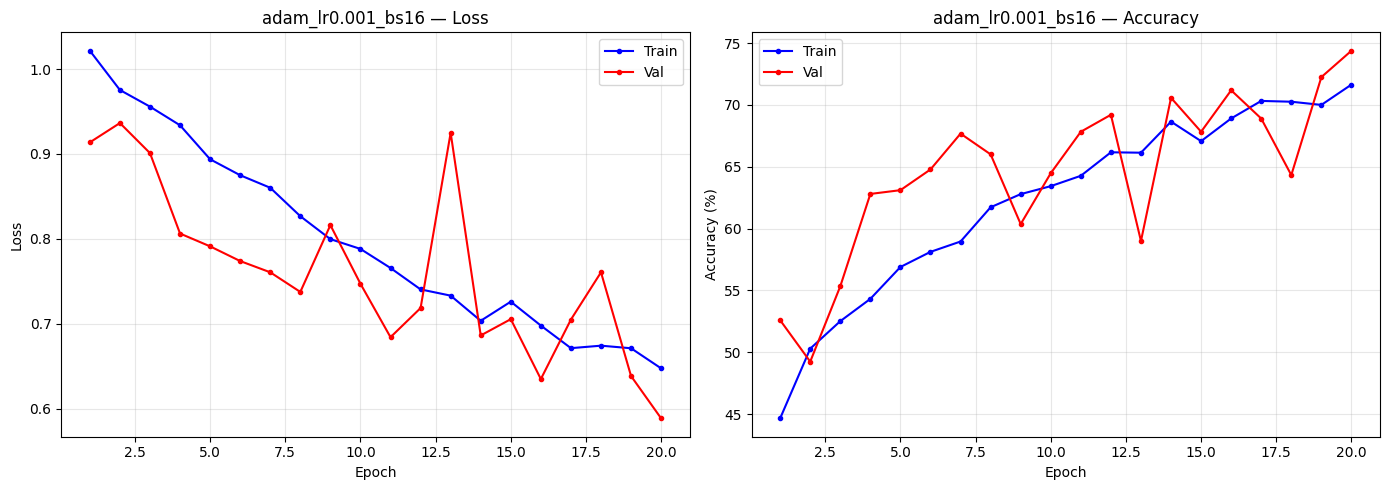

  [adam_lr0.001_bs16] FINAL TEST RESULTS
  Loss      : 0.5757
  Accuracy  : 77.13%
  Precision : 0.7705  (weighted)
  Recall    : 0.7713    (weighted)
  F1-score  : 0.7696       (weighted)
              precision    recall  f1-score   support

    acoustic     0.7899    0.8638    0.8252       235
        bass     0.7651    0.6791    0.7195       187
    electric     0.7554    0.7521    0.7537       234

    accuracy                         0.7713       656
   macro avg     0.7701    0.7650    0.7662       656
weighted avg     0.7705    0.7713    0.7696       656



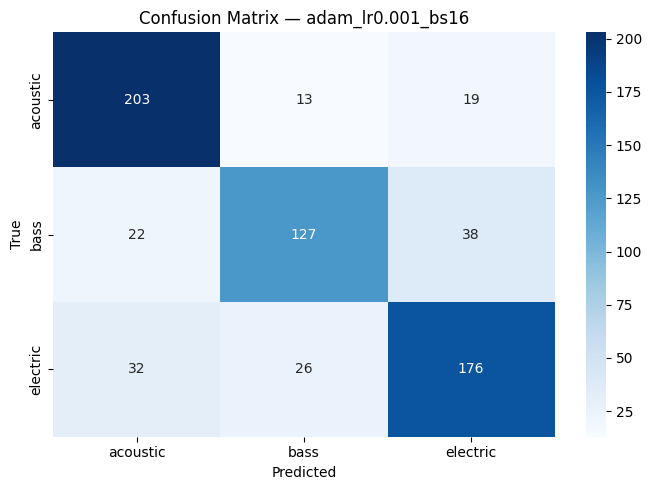

  RUN: optimizer=adam  lr=0.001  batch_size=32
[INFO] Classes    : ['acoustic', 'bass', 'electric']
[INFO] Total      : 4436
[INFO]   Train    : 3105 | Val: 665 | Test: 666

[INFO] ImprovedCNN — trainable params: 3,143,971
  Training: adam_lr0.001_bs32  |  epochs=20
Epoch [ 1/20]  Train 1.0025/48.1%  Val 0.8709/58.9%  (16.2s)  ✓ best
Epoch [ 2/20]  Train 0.9283/55.4%  Val 0.9332/54.1%  (16.1s)
Epoch [ 3/20]  Train 0.8801/58.0%  Val 1.1202/53.9%  (16.2s)
Epoch [ 4/20]  Train 0.8520/61.0%  Val 0.7270/67.7%  (16.2s)  ✓ best
Epoch [ 5/20]  Train 0.8100/62.6%  Val 0.8126/61.1%  (15.9s)
Epoch [18/20]  Train 0.6092/73.0%  Val 0.9128/62.8%  (16.0s)
Epoch [19/20]  Train 0.6089/74.0%  Val 0.5724/75.2%  (16.1s)  ✓ best
Epoch [20/20]  Train 0.5902/74.8%  Val 0.6909/72.5%  (15.8s)

  Best val acc: 75.16%  |  saved → ./best_adam_lr0.001_bs32.pth


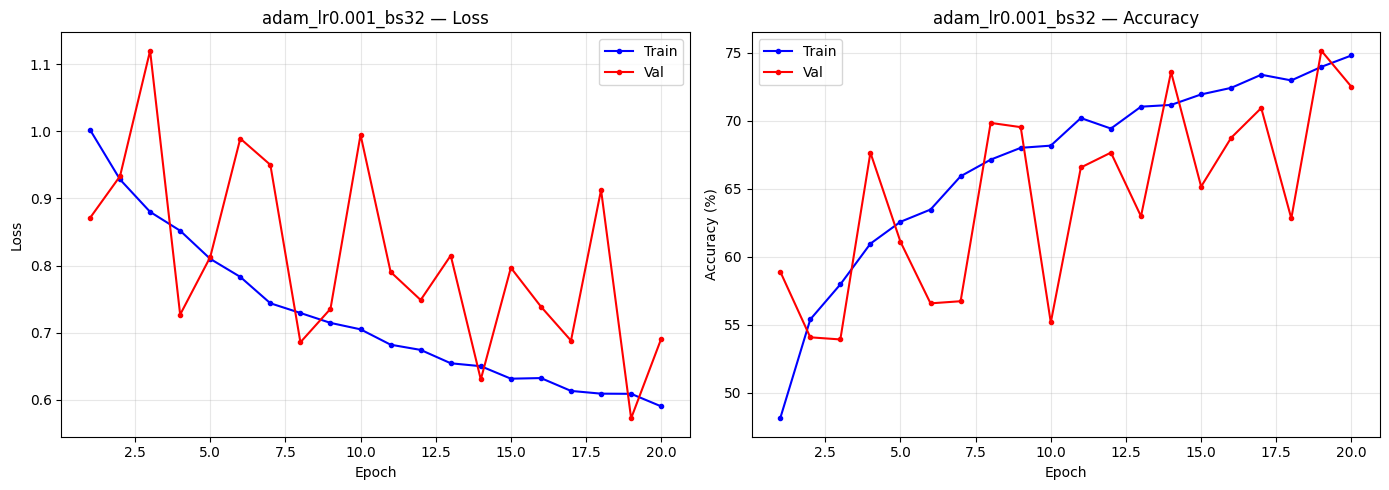

  [adam_lr0.001_bs32] FINAL TEST RESULTS
  Loss      : 0.5623
  Accuracy  : 76.41%
  Precision : 0.7643  (weighted)
  Recall    : 0.7641    (weighted)
  F1-score  : 0.7604       (weighted)
              precision    recall  f1-score   support

    acoustic     0.7698    0.8908    0.8259       229
        bass     0.7755    0.6264    0.6930       182
    electric     0.7500    0.7467    0.7484       229

    accuracy                         0.7641       640
   macro avg     0.7651    0.7546    0.7558       640
weighted avg     0.7643    0.7641    0.7604       640



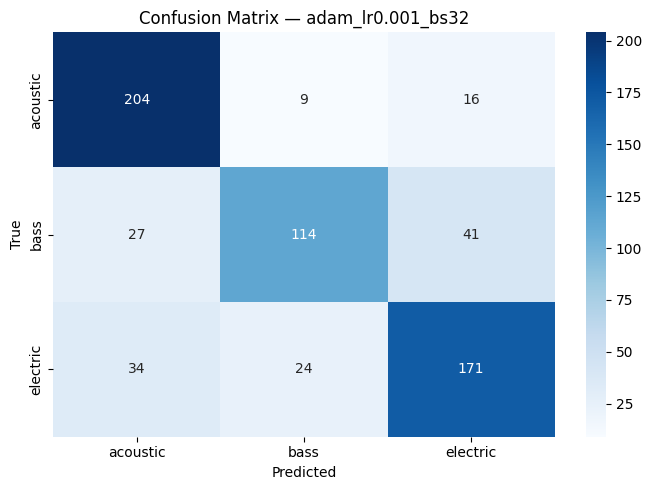

  RUN: optimizer=adam  lr=0.001  batch_size=64
[INFO] Classes    : ['acoustic', 'bass', 'electric']
[INFO] Total      : 4436
[INFO]   Train    : 3105 | Val: 665 | Test: 666

[INFO] ImprovedCNN — trainable params: 3,143,971
  Training: adam_lr0.001_bs64  |  epochs=20
Epoch [ 1/20]  Train 1.0190/47.2%  Val 1.1915/47.7%  (16.0s)  ✓ best
Epoch [ 2/20]  Train 0.9669/52.4%  Val 0.9243/55.3%  (15.8s)  ✓ best
Epoch [ 3/20]  Train 0.9174/56.2%  Val 0.8969/58.3%  (16.0s)  ✓ best
Epoch [ 4/20]  Train 0.8814/57.5%  Val 0.9117/55.9%  (16.1s)
Epoch [ 5/20]  Train 0.8422/59.9%  Val 1.0893/53.1%  (15.6s)
Epoch [ 6/20]  Train 0.8228/61.1%  Val 0.7223/67.7%  (16.2s)  ✓ best
Epoch [ 7/20]  Train 0.7854/64.1%  Val 0.7372/64.8%  (15.8s)
Epoch [ 8/20]  Train 0.7647/64.2%  Val 0.7686/65.6%  (16.1s)
Epoch [ 9/20]  Train 0.7433/65.3%  Val 0.8336/60.9%  (15.9s)
Epoch [10/20]  Train 0.7138/68.1%  Val 0.7091/67.8%  (15.7s)  ✓ best
Epoch [11/20]  Train 0.7098/67.6%  Val 0.9901/59.1%  (15.9s)
Epoch [12/20]  Train 0

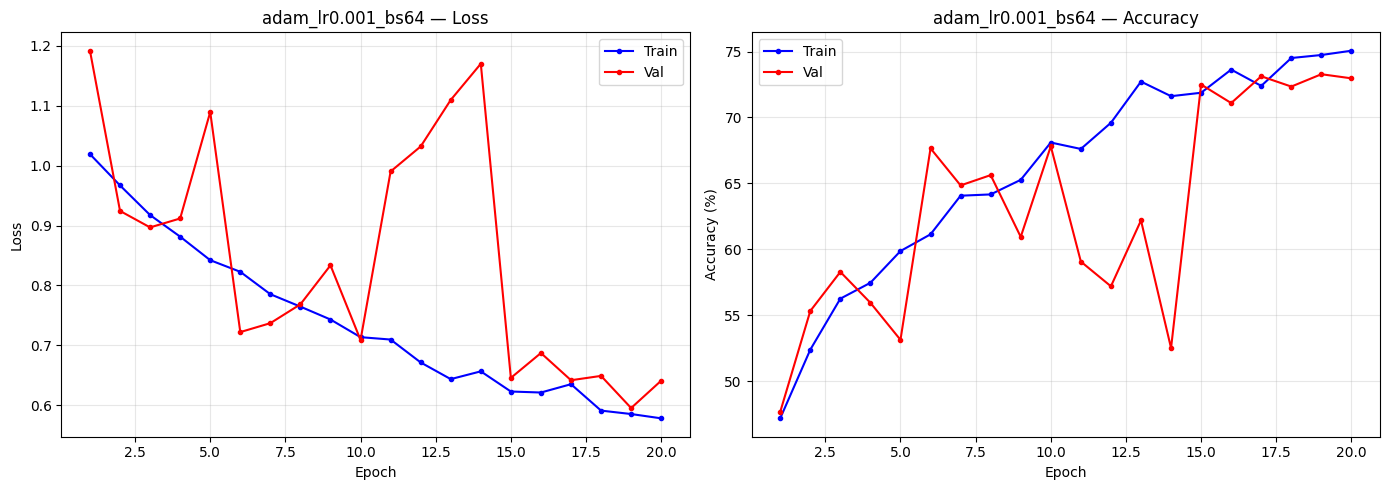

  [adam_lr0.001_bs64] FINAL TEST RESULTS
  Loss      : 0.6100
  Accuracy  : 73.28%
  Precision : 0.7346  (weighted)
  Recall    : 0.7328    (weighted)
  F1-score  : 0.7335       (weighted)
              precision    recall  f1-score   support

    acoustic     0.8082    0.7729    0.7902       229
        bass     0.6811    0.6923    0.6866       182
    electric     0.7034    0.7249    0.7140       229

    accuracy                         0.7328       640
   macro avg     0.7309    0.7300    0.7303       640
weighted avg     0.7346    0.7328    0.7335       640



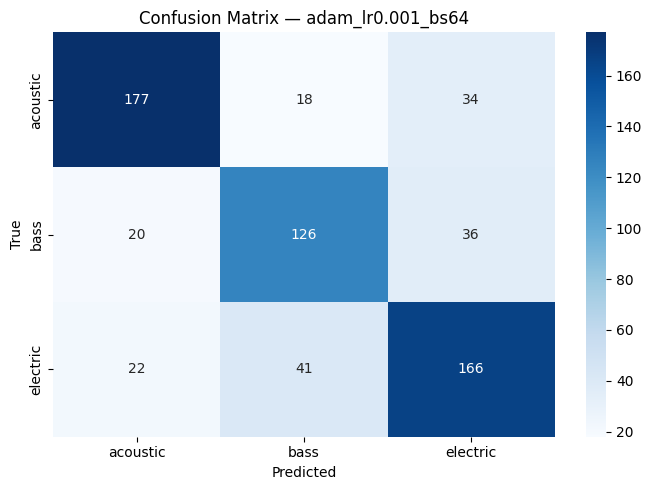

  RUN: optimizer=adam  lr=0.0001  batch_size=16
[INFO] Classes    : ['acoustic', 'bass', 'electric']
[INFO] Total      : 4436
[INFO]   Train    : 3105 | Val: 665 | Test: 666

[INFO] ImprovedCNN — trainable params: 3,143,971
  Training: adam_lr0.0001_bs16  |  epochs=20
Epoch [ 1/20]  Train 1.0163/46.2%  Val 0.9548/51.2%  (16.0s)  ✓ best
Epoch [ 2/20]  Train 0.9632/53.1%  Val 1.0218/48.2%  (16.0s)
Epoch [ 3/20]  Train 0.9027/56.3%  Val 1.1661/44.4%  (16.0s)
Epoch [ 4/20]  Train 0.8654/59.8%  Val 0.9385/51.5%  (16.0s)  ✓ best
Epoch [ 5/20]  Train 0.8431/60.8%  Val 0.8231/62.2%  (15.9s)  ✓ best
Epoch [ 6/20]  Train 0.7922/62.9%  Val 0.7162/68.4%  (16.0s)  ✓ best
Epoch [ 7/20]  Train 0.7714/65.6%  Val 0.7433/66.8%  (15.8s)
Epoch [ 8/20]  Train 0.7487/65.6%  Val 0.6870/68.8%  (15.8s)  ✓ best
Epoch [ 9/20]  Train 0.7262/66.9%  Val 0.6723/67.5%  (16.0s)
Epoch [10/20]  Train 0.6980/68.8%  Val 0.6284/73.5%  (16.0s)  ✓ best
Epoch [11/20]  Train 0.6825/70.2%  Val 0.7070/71.8%  (16.0s)
Epoch [12/20

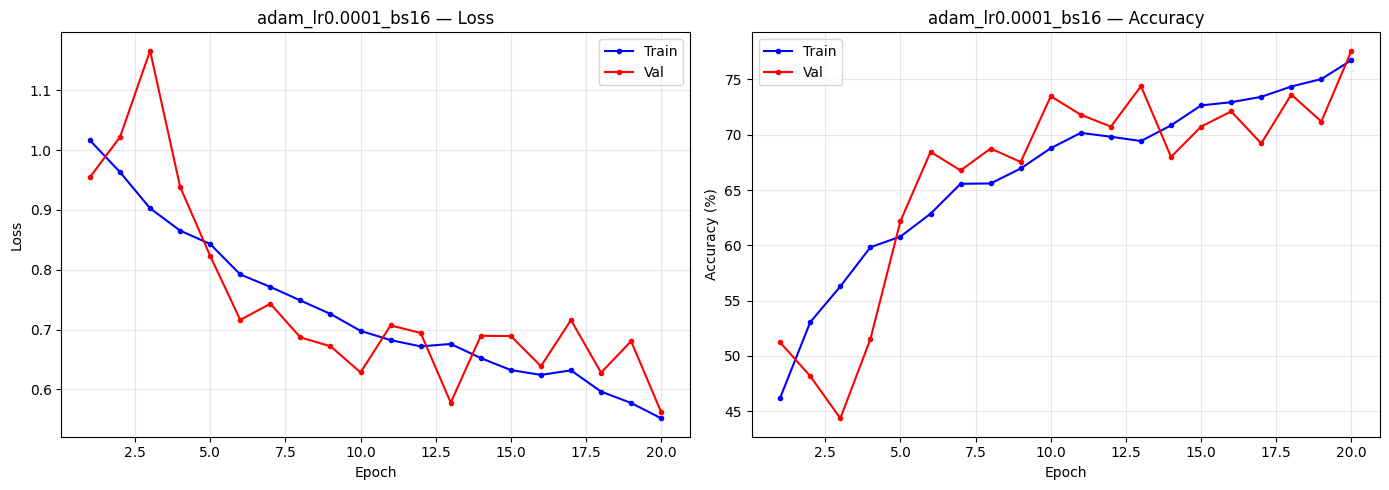

  [adam_lr0.0001_bs16] FINAL TEST RESULTS
  Loss      : 0.5375
  Accuracy  : 80.64%
  Precision : 0.8068  (weighted)
  Recall    : 0.8064    (weighted)
  F1-score  : 0.8053       (weighted)
              precision    recall  f1-score   support

    acoustic     0.8361    0.8681    0.8518       235
        bass     0.8110    0.7112    0.7578       187
    electric     0.7742    0.8205    0.7967       234

    accuracy                         0.8064       656
   macro avg     0.8071    0.7999    0.8021       656
weighted avg     0.8068    0.8064    0.8053       656



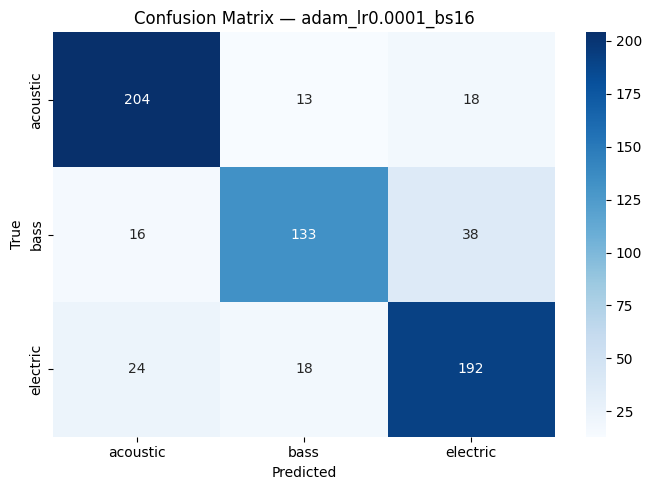

  RUN: optimizer=adam  lr=0.0001  batch_size=32
[INFO] Classes    : ['acoustic', 'bass', 'electric']
[INFO] Total      : 4436
[INFO]   Train    : 3105 | Val: 665 | Test: 666

[INFO] ImprovedCNN — trainable params: 3,143,971
  Training: adam_lr0.0001_bs32  |  epochs=20
Epoch [ 1/20]  Train 1.0263/46.4%  Val 0.9384/58.1%  (16.3s)  ✓ best
Epoch [ 2/20]  Train 0.9484/53.6%  Val 0.9918/50.3%  (16.2s)
Epoch [ 3/20]  Train 0.9095/55.8%  Val 0.9505/53.0%  (16.3s)
Epoch [ 4/20]  Train 0.8627/59.7%  Val 0.8836/57.7%  (16.1s)
Epoch [ 5/20]  Train 0.8246/61.4%  Val 0.7716/66.2%  (16.2s)  ✓ best
Epoch [ 6/20]  Train 0.7947/63.7%  Val 0.7875/62.5%  (16.0s)
Epoch [ 7/20]  Train 0.7521/66.8%  Val 0.7503/64.8%  (16.3s)
Epoch [ 8/20]  Train 0.7432/66.3%  Val 0.6769/70.5%  (16.0s)  ✓ best
Epoch [ 9/20]  Train 0.7083/69.1%  Val 0.9067/59.8%  (16.4s)
Epoch [10/20]  Train 0.6965/69.0%  Val 0.6706/67.5%  (16.3s)
Epoch [11/20]  Train 0.6770/71.1%  Val 0.6763/71.1%  (16.3s)  ✓ best
Epoch [12/20]  Train 0.6707/

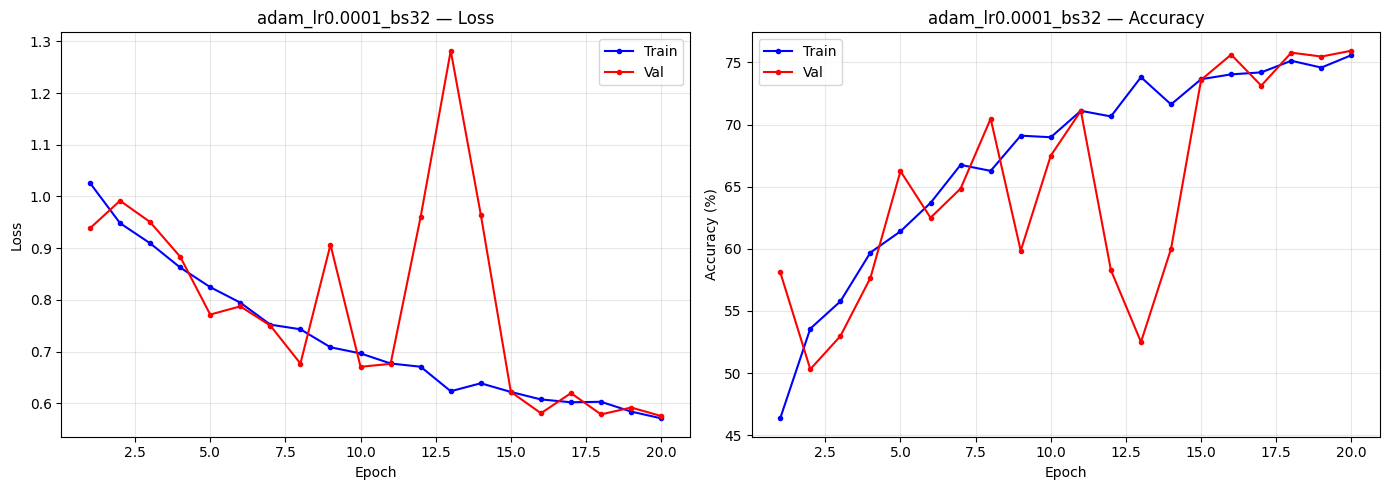

  [adam_lr0.0001_bs32] FINAL TEST RESULTS
  Loss      : 0.5770
  Accuracy  : 78.28%
  Precision : 0.7890  (weighted)
  Recall    : 0.7828    (weighted)
  F1-score  : 0.7841       (weighted)
              precision    recall  f1-score   support

    acoustic     0.8806    0.7729    0.8233       229
        bass     0.7358    0.7802    0.7573       182
    electric     0.7398    0.7948    0.7663       229

    accuracy                         0.7828       640
   macro avg     0.7854    0.7826    0.7823       640
weighted avg     0.7890    0.7828    0.7841       640



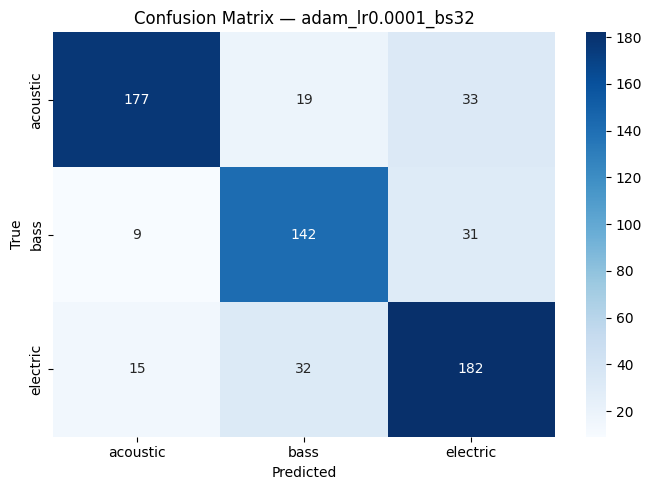

  RUN: optimizer=adam  lr=0.0001  batch_size=64
[INFO] Classes    : ['acoustic', 'bass', 'electric']
[INFO] Total      : 4436
[INFO]   Train    : 3105 | Val: 665 | Test: 666

[INFO] ImprovedCNN — trainable params: 3,143,971
  Training: adam_lr0.0001_bs64  |  epochs=20
Epoch [ 1/20]  Train 1.0458/43.6%  Val 0.9747/52.8%  (16.0s)  ✓ best
Epoch [ 2/20]  Train 0.9817/49.7%  Val 0.9139/56.9%  (16.0s)  ✓ best
Epoch [ 3/20]  Train 0.9366/54.2%  Val 0.8857/57.8%  (16.0s)  ✓ best
Epoch [ 4/20]  Train 0.8996/57.1%  Val 0.9457/53.4%  (16.0s)
Epoch [ 5/20]  Train 0.8475/60.5%  Val 0.8873/58.0%  (16.1s)  ✓ best
Epoch [ 6/20]  Train 0.8267/61.8%  Val 0.7605/63.4%  (16.1s)  ✓ best
Epoch [ 7/20]  Train 0.7886/65.0%  Val 0.7448/67.3%  (15.8s)  ✓ best
Epoch [ 8/20]  Train 0.7662/65.8%  Val 0.6851/72.2%  (15.8s)  ✓ best
Epoch [ 9/20]  Train 0.7500/66.2%  Val 0.6675/70.8%  (16.3s)
Epoch [10/20]  Train 0.7256/67.7%  Val 0.6671/70.9%  (16.2s)
Epoch [11/20]  Train 0.7213/67.6%  Val 0.6946/71.6%  (16.1s)
Epoc

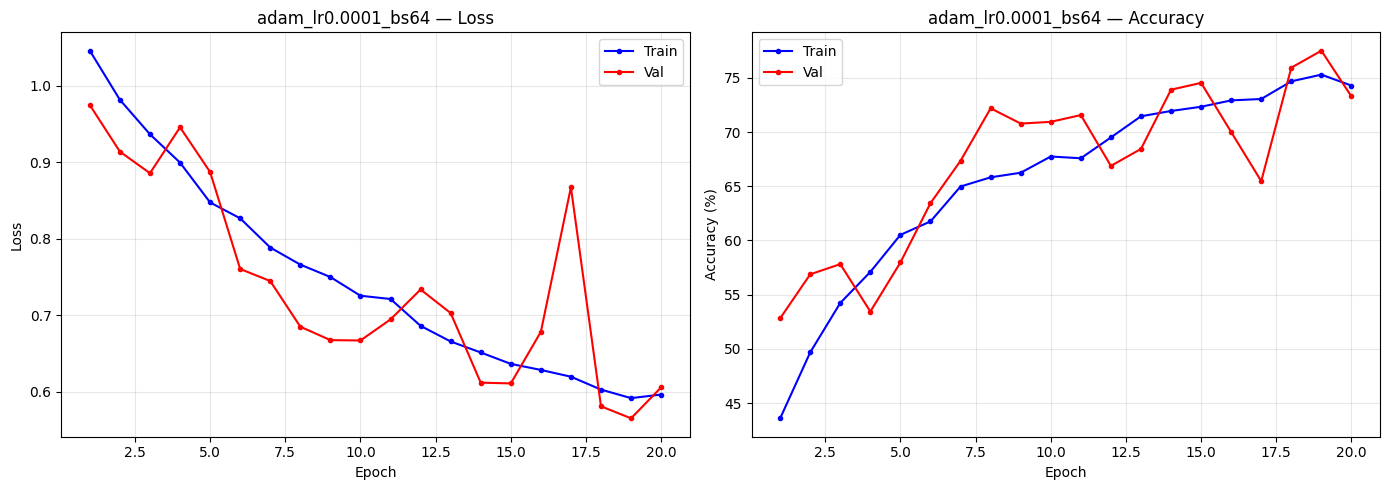

  [adam_lr0.0001_bs64] FINAL TEST RESULTS
  Loss      : 0.5900
  Accuracy  : 76.25%
  Precision : 0.7659  (weighted)
  Recall    : 0.7625    (weighted)
  F1-score  : 0.7632       (weighted)
              precision    recall  f1-score   support

    acoustic     0.8364    0.7817    0.8081       229
        bass     0.7471    0.7143    0.7303       182
    electric     0.7103    0.7817    0.7443       229

    accuracy                         0.7625       640
   macro avg     0.7646    0.7592    0.7609       640
weighted avg     0.7659    0.7625    0.7632       640



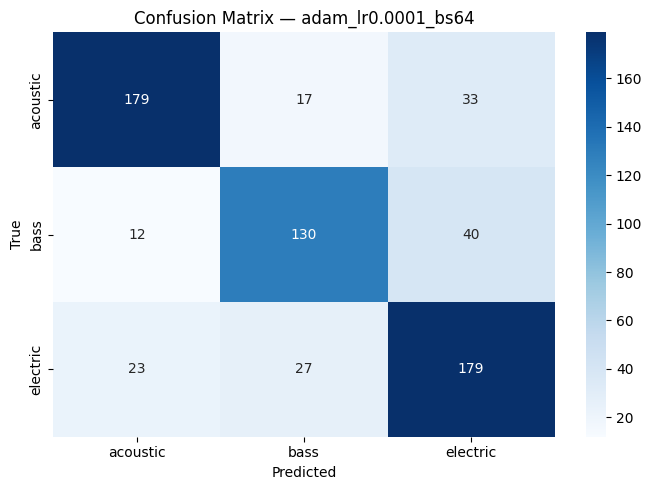

  RUN: optimizer=adam  lr=5e-05  batch_size=16
[INFO] Classes    : ['acoustic', 'bass', 'electric']
[INFO] Total      : 4436
[INFO]   Train    : 3105 | Val: 665 | Test: 666

[INFO] ImprovedCNN — trainable params: 3,143,971
  Training: adam_lr5e-05_bs16  |  epochs=20
Epoch [ 1/20]  Train 1.0269/46.1%  Val 0.9325/59.0%  (16.0s)  ✓ best
Epoch [ 2/20]  Train 0.9753/52.0%  Val 0.8811/60.7%  (16.0s)  ✓ best
Epoch [ 3/20]  Train 0.9361/54.8%  Val 0.8812/57.9%  (16.1s)
Epoch [ 4/20]  Train 0.9043/56.8%  Val 0.9153/52.7%  (15.8s)
Epoch [ 5/20]  Train 0.8722/59.1%  Val 0.8000/63.6%  (15.9s)  ✓ best
Epoch [ 6/20]  Train 0.8563/60.8%  Val 0.7873/64.0%  (15.9s)  ✓ best
Epoch [ 7/20]  Train 0.8209/61.8%  Val 0.9685/52.0%  (16.0s)
Epoch [ 8/20]  Train 0.8127/62.8%  Val 0.8711/59.6%  (16.2s)
Epoch [ 9/20]  Train 0.7773/65.1%  Val 0.7062/69.5%  (16.0s)  ✓ best
Epoch [10/20]  Train 0.7563/65.1%  Val 0.7235/67.5%  (15.8s)
Epoch [11/20]  Train 0.7443/66.5%  Val 0.7916/65.9%  (16.2s)
Epoch [12/20]  Train 0

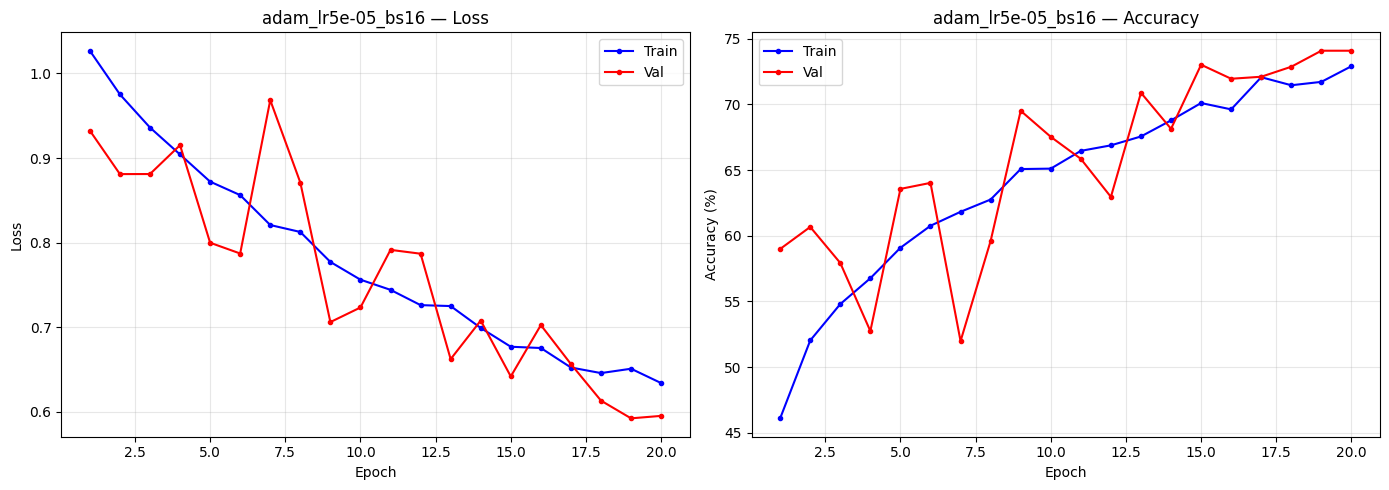

  [adam_lr5e-05_bs16] FINAL TEST RESULTS
  Loss      : 0.6165
  Accuracy  : 73.78%
  Precision : 0.7436  (weighted)
  Recall    : 0.7378    (weighted)
  F1-score  : 0.7386       (weighted)
              precision    recall  f1-score   support

    acoustic     0.8243    0.7787    0.8009       235
        bass     0.6545    0.7701    0.7076       187
    electric     0.7336    0.6709    0.7009       234

    accuracy                         0.7378       656
   macro avg     0.7375    0.7399    0.7365       656
weighted avg     0.7436    0.7378    0.7386       656



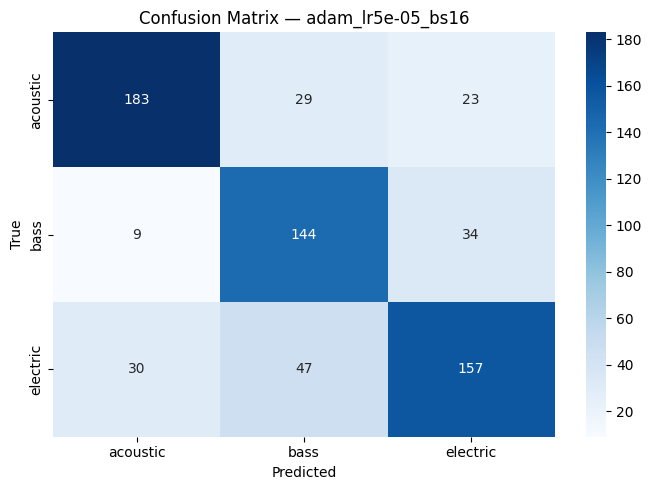

  RUN: optimizer=adam  lr=5e-05  batch_size=32
[INFO] Classes    : ['acoustic', 'bass', 'electric']
[INFO] Total      : 4436
[INFO]   Train    : 3105 | Val: 665 | Test: 666

[INFO] ImprovedCNN — trainable params: 3,143,971
  Training: adam_lr5e-05_bs32  |  epochs=20
Epoch [ 1/20]  Train 1.0387/43.1%  Val 0.9657/54.4%  (15.9s)  ✓ best
Epoch [ 2/20]  Train 0.9835/50.7%  Val 0.9145/55.9%  (16.1s)  ✓ best
Epoch [ 3/20]  Train 0.9461/53.5%  Val 0.9073/55.9%  (15.9s)
Epoch [ 4/20]  Train 0.9099/57.3%  Val 0.8503/60.8%  (15.9s)  ✓ best
Epoch [ 5/20]  Train 0.8882/57.2%  Val 0.9443/55.9%  (15.6s)
Epoch [ 6/20]  Train 0.8743/59.1%  Val 0.7840/65.8%  (15.9s)  ✓ best
Epoch [ 7/20]  Train 0.8420/61.3%  Val 0.8524/61.7%  (15.9s)
Epoch [ 8/20]  Train 0.8178/63.3%  Val 0.7390/67.0%  (15.9s)  ✓ best
Epoch [ 9/20]  Train 0.7971/64.0%  Val 0.7422/65.9%  (15.7s)
Epoch [10/20]  Train 0.7786/64.7%  Val 0.7485/65.9%  (15.7s)
Epoch [11/20]  Train 0.7571/67.0%  Val 0.6755/70.0%  (16.0s)  ✓ best
Epoch [12/20] 

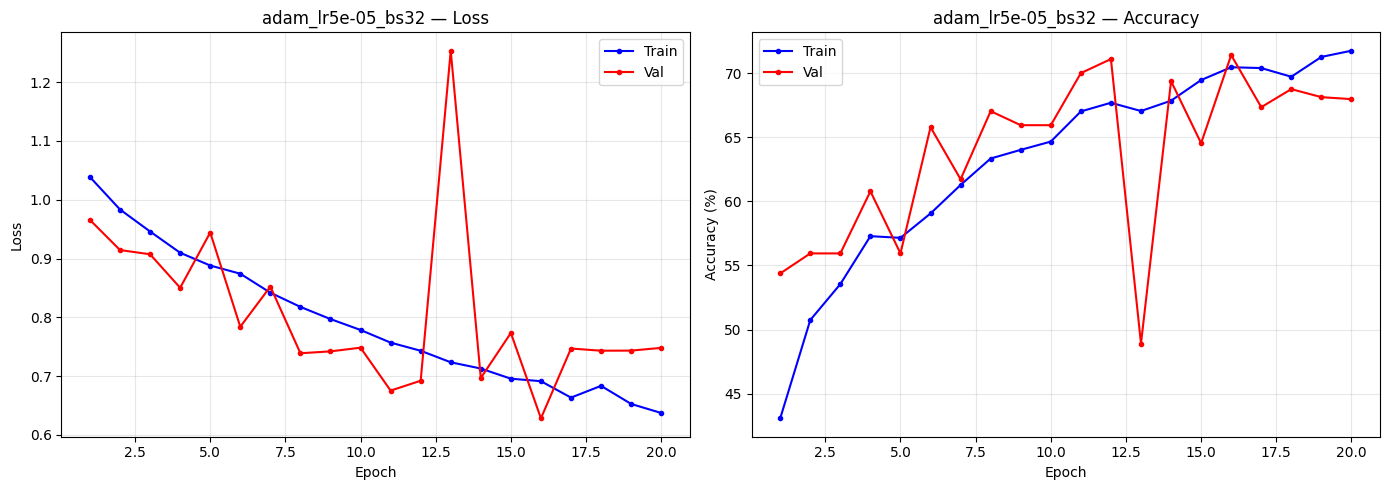

  [adam_lr5e-05_bs32] FINAL TEST RESULTS
  Loss      : 0.6491
  Accuracy  : 70.47%
  Precision : 0.7062  (weighted)
  Recall    : 0.7047    (weighted)
  F1-score  : 0.7025       (weighted)
              precision    recall  f1-score   support

    acoustic     0.7510    0.7904    0.7702       229
        bass     0.6490    0.7418    0.6923       182
    electric     0.7068    0.5895    0.6429       229

    accuracy                         0.7047       640
   macro avg     0.7023    0.7072    0.7018       640
weighted avg     0.7062    0.7047    0.7025       640



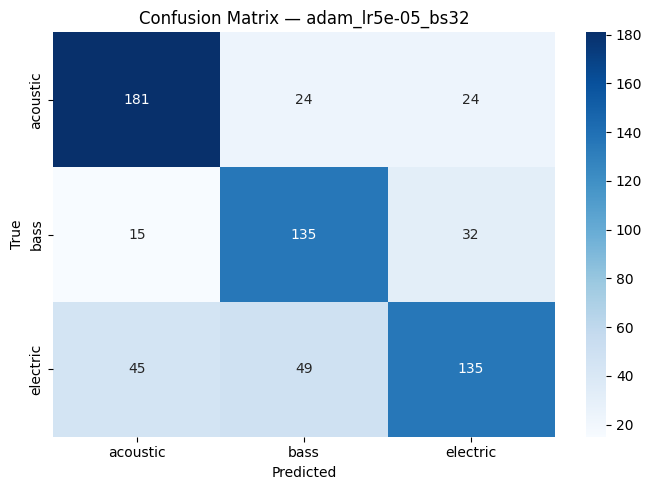

  RUN: optimizer=adam  lr=5e-05  batch_size=64
[INFO] Classes    : ['acoustic', 'bass', 'electric']
[INFO] Total      : 4436
[INFO]   Train    : 3105 | Val: 665 | Test: 666

[INFO] ImprovedCNN — trainable params: 3,143,971
  Training: adam_lr5e-05_bs64  |  epochs=20
Epoch [ 1/20]  Train 1.0561/43.0%  Val 0.9696/55.5%  (16.6s)  ✓ best
Epoch [ 2/20]  Train 0.9906/50.2%  Val 0.9141/58.9%  (16.3s)  ✓ best
Epoch [ 3/20]  Train 0.9628/51.2%  Val 0.8865/61.7%  (16.3s)  ✓ best
Epoch [ 4/20]  Train 0.9304/55.4%  Val 0.8716/63.4%  (16.3s)  ✓ best
Epoch [ 5/20]  Train 0.9122/56.1%  Val 0.8409/65.3%  (16.3s)  ✓ best
Epoch [ 6/20]  Train 0.8875/57.8%  Val 0.9861/51.1%  (16.3s)
Epoch [ 7/20]  Train 0.8604/61.4%  Val 0.8118/62.3%  (16.4s)
Epoch [ 8/20]  Train 0.8395/61.2%  Val 0.8888/57.2%  (16.7s)
Epoch [ 9/20]  Train 0.8334/61.4%  Val 0.8650/61.3%  (16.4s)
Epoch [10/20]  Train 0.8051/62.5%  Val 0.8701/60.2%  (16.2s)
Epoch [11/20]  Train 0.7887/64.1%  Val 0.7256/70.0%  (16.3s)  ✓ best
Epoch [12/20] 

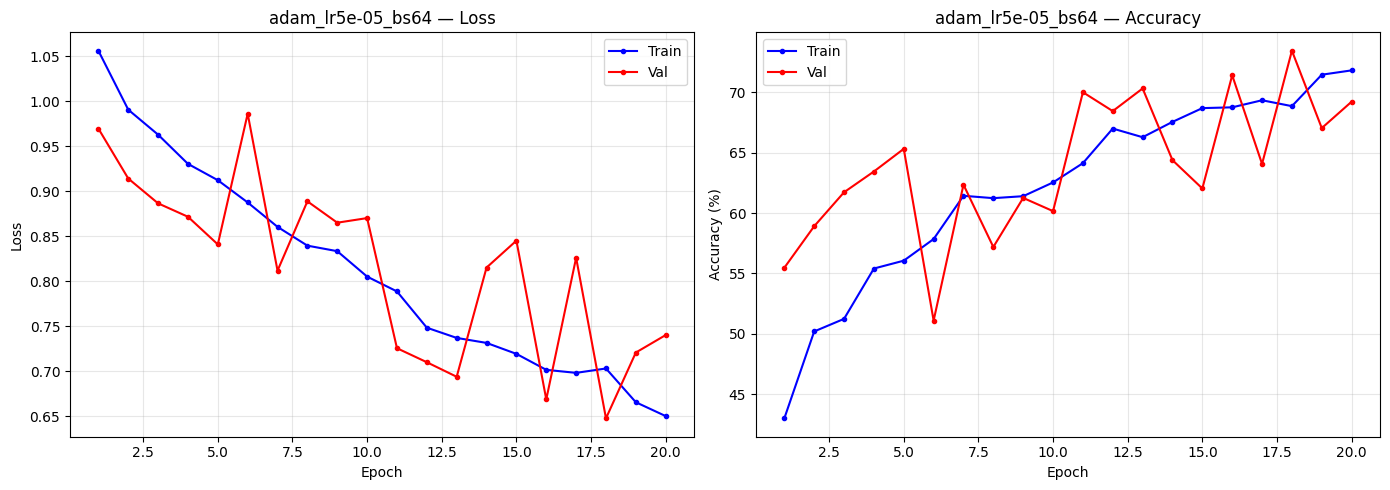

  [adam_lr5e-05_bs64] FINAL TEST RESULTS
  Loss      : 0.6780
  Accuracy  : 68.12%
  Precision : 0.6988  (weighted)
  Recall    : 0.6813    (weighted)
  F1-score  : 0.6828       (weighted)
              precision    recall  f1-score   support

    acoustic     0.8087    0.6463    0.7184       229
        bass     0.5892    0.7802    0.6714       182
    electric     0.6759    0.6376    0.6562       229

    accuracy                         0.6813       640
   macro avg     0.6913    0.6880    0.6820       640
weighted avg     0.6988    0.6813    0.6828       640



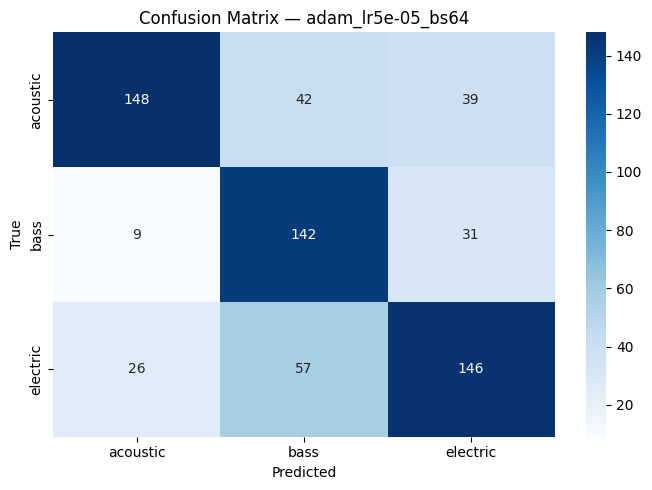

In [20]:
results_table = []  # Stores summary dicts for all runs

for opt_name, lr, bs in itertools.product(OPTIMIZERS, LEARNING_RATES, BATCH_SIZES):

    run_name = f"{opt_name}_lr{lr}_bs{bs}"
    
    print(f"  RUN: optimizer={opt_name}  lr={lr}  batch_size={bs}")
    

    #  Data 
    train_loader, val_loader, test_loader, class_names = load_data(bs)

    #  Model, loss, optimizer 
    model     = build_model(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, opt_name, lr)

    #  Train 
    model, history = train_model(
        model, train_loader, val_loader, criterion,
        optimizer, device, num_epochs=NUM_EPOCHS, run_name=run_name
    )

    #  Plot curves for this run 
    plot_training_curves(history, title=run_name)

    #  Evaluate on test 
    metrics = full_evaluation(
        model, test_loader, criterion, device, class_names, run_name=run_name)
    results_table.append(metrics)

    plot_confusion_matrix(
        metrics["labels"], metrics["preds"], class_names,
        title=f"Confusion Matrix — {run_name}"
    )

## 10. Results Summary and Best Run

In [21]:

print(f"  HYPERPARAMETER SEARCH SUMMARY")

print(f"{'Run':<35} {'Acc%':>7} {'F1':>7} {'Prec':>7} {'Recall':>7}")


for r in sorted(results_table, key=lambda x: x["acc"], reverse=True):
    print(f"{r['run']:<35} {r['acc']*100:>6.2f}% {r['f1']:>7.4f} "
          f"{r['precision']:>7.4f} {r['recall']:>7.4f}")

best_run = max(results_table, key=lambda x: x["acc"])
print(f"\n  ✓ Best configuration: {best_run['run']}")
print(f"    Test Accuracy : {best_run['acc']*100:.2f}%")
print(f"    F1 Score      : {best_run['f1']:.4f}")

  HYPERPARAMETER SEARCH SUMMARY
Run                                    Acc%      F1    Prec  Recall
adam_lr0.0001_bs16                   80.64%  0.8053  0.8068  0.8064
adam_lr0.0001_bs32                   78.28%  0.7841  0.7890  0.7828
adam_lr0.001_bs16                    77.13%  0.7696  0.7705  0.7713
adam_lr0.001_bs32                    76.41%  0.7604  0.7643  0.7641
adam_lr0.0001_bs64                   76.25%  0.7632  0.7659  0.7625
adam_lr5e-05_bs16                    73.78%  0.7386  0.7436  0.7378
adam_lr0.001_bs64                    73.28%  0.7335  0.7346  0.7328
adam_lr5e-05_bs32                    70.47%  0.7025  0.7062  0.7047
adam_lr5e-05_bs64                    68.12%  0.6828  0.6988  0.6813

  ✓ Best configuration: adam_lr0.0001_bs16
    Test Accuracy : 80.64%
    F1 Score      : 0.8053


## 11. Best Model — Final Visualisations


[INFO] ImprovedCNN — trainable params: 3,143,971
[INFO] Classes    : ['acoustic', 'bass', 'electric']
[INFO] Total      : 4436
[INFO]   Train    : 3105 | Val: 665 | Test: 666


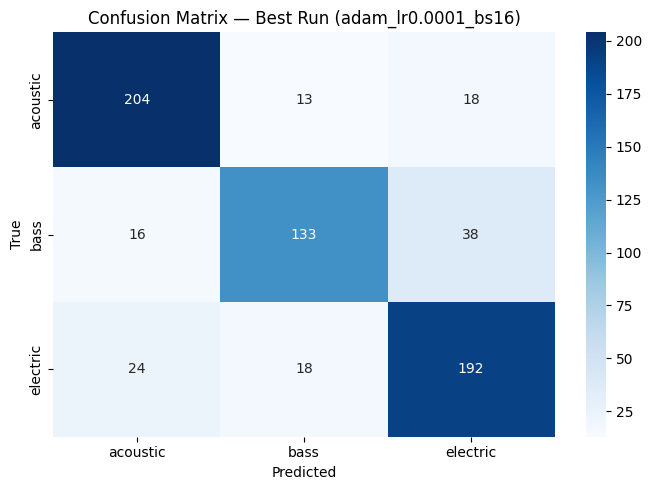

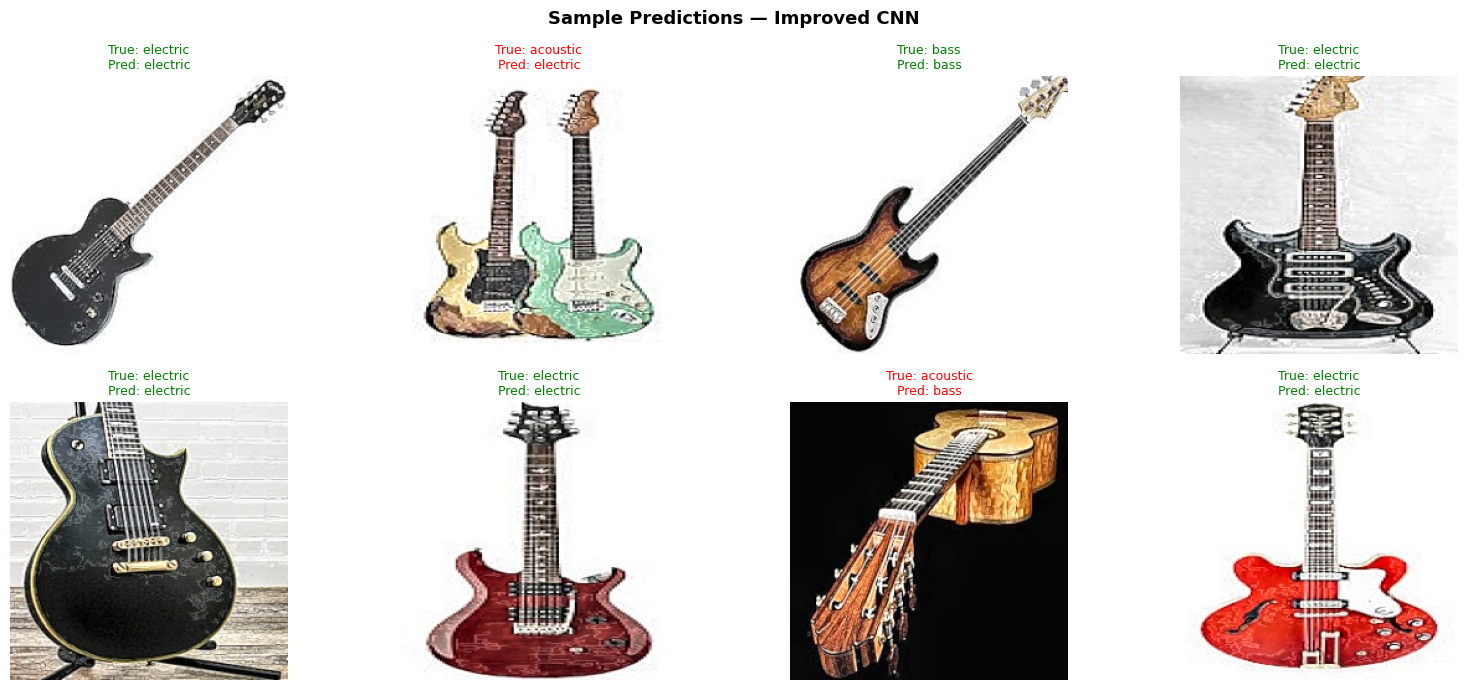

In [22]:
# Reload best model weights and run final plots
best_save = os.path.join(SAVE_DIR, f"best_{best_run['run']}.pth")
best_model = build_model(device)
best_model.load_state_dict(torch.load(best_save, map_location=device))

# Use the batch size from the best run
best_bs = int(best_run["run"].split("_bs")[-1])
_, _, test_loader_best, class_names = load_data(best_bs)

plot_confusion_matrix(
    best_run["labels"], best_run["preds"], class_names,
    title=f"Confusion Matrix — Best Run ({best_run['run']})"
)

show_sample_predictions(best_model, test_loader_best, class_names, device)

## 12. Comparison: Baseline CNN vs Improved CNN

Paste your Baseline CNN test accuracy into `BASELINE_ACC` below.

  MODEL COMPARISON
  Baseline CNN   Test Accuracy : 68.27%
  Improved CNN   Test Accuracy : 80.64%
  Improvement                  : +12.37 percentage points


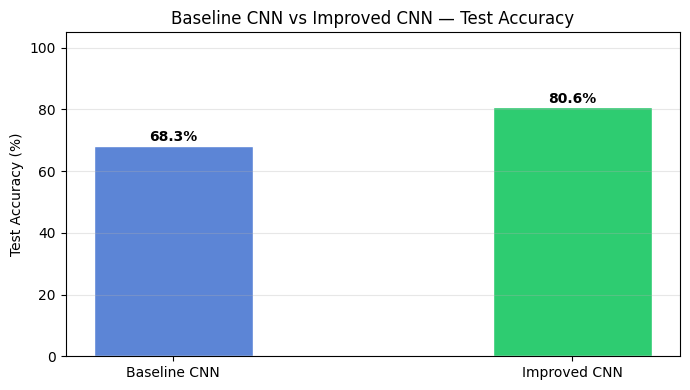

In [23]:
BASELINE_ACC = 0.6827    # ← Replace with your actual baseline test accuracy

best_acc = best_run["acc"]
delta    = (best_acc - BASELINE_ACC) * 100


print(f"  MODEL COMPARISON")

print(f"  Baseline CNN   Test Accuracy : {BASELINE_ACC*100:.2f}%")
print(f"  Improved CNN   Test Accuracy : {best_acc*100:.2f}%")
print(f"  Improvement                  : +{delta:.2f} percentage points")


labels_plot  = ["Baseline CNN", "Improved CNN"]
accs_plot    = [BASELINE_ACC * 100, best_acc * 100]
colors       = ["#5c85d6", "#2ecc71"]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels_plot, accs_plot, color=colors, edgecolor="white", width=0.4)
for bar, acc in zip(bars, accs_plot):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{acc:.1f}%", ha="center", va="bottom", fontweight="bold")
plt.ylim(0, 105)
plt.ylabel("Test Accuracy (%)")
plt.title("Baseline CNN vs Improved CNN — Test Accuracy")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

### What was improved over the Baseline CNN

| Feature                  | Baseline CNN      | Improved CNN                        |
|--------------------------|-------------------|-------------------------------------|
| Preprocessing            | None              | Background crop, CLAHE, sharpen     |
| Conv blocks              | 3                 | 5                                   |
| Batch Normalisation      | ✗                 | ✓ (every conv + FC1)                |
| Dropout                  | ✗                 | ✓ 0.5 (features) / 0.3 (FC)        |
| Data augmentation        | None              | Flip, Rotate, Crop, ColorJitter     |
| Optimizer                | Adam only         | Adam vs SGD (grid search)           |
| LR scheduling            | Fixed             | ReduceLROnPlateau                   |